In [1]:
import numpy   as np
import pandas  as pd
import seaborn as sns

import plotly.express as px
import matplotlib.pyplot as plt

In [2]:
df_community_0 = pd.read_csv("../data/communities/by_color/df_community_0.csv")
df_community_1 = pd.read_csv("../data/communities/by_color/df_community_1.csv")
df_community_2 = pd.read_csv("../data/communities/by_color/df_community_2.csv")
df_community_3 = pd.read_csv("../data/communities/by_color/df_community_3.csv")
df_community_4 = pd.read_csv("../data/communities/by_color/df_community_4.csv")
df_community_5 = pd.read_csv("../data/communities/by_color/df_community_5.csv")

In [3]:
dfs = [df_community_0, df_community_1, df_community_2, df_community_3, df_community_4, df_community_5]

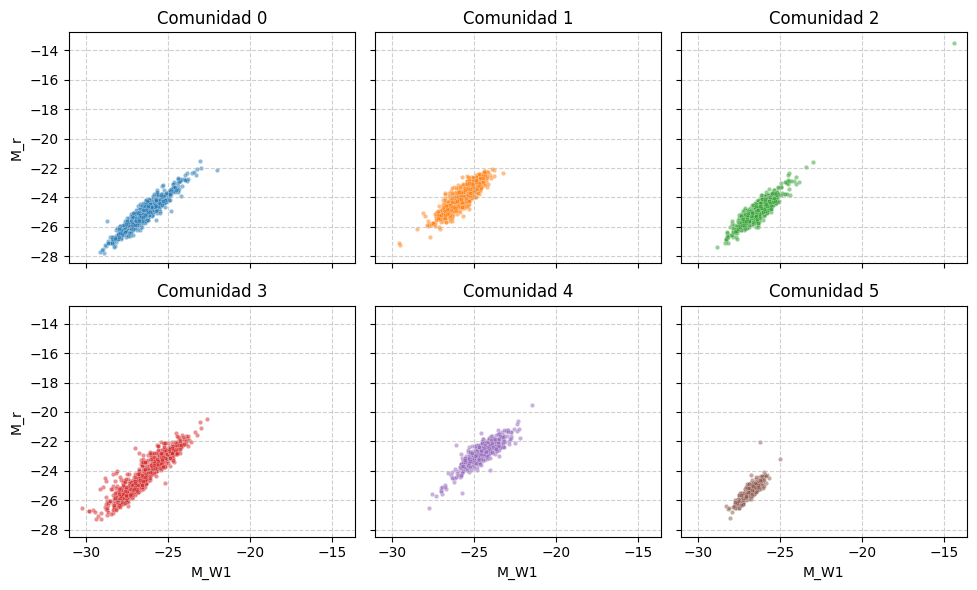

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten() # Aplanamos la matriz de 3x2 a un array de 6 para el loop

# Definimos qué columnas queremos graficar
color_x = 'M_W1'
color_y = 'M_r'

for i, df_temp in enumerate(dfs):
    ax = axes[i]
    
    # Graficamos un scatter plot o un hexbin (si hay muchos puntos)
    sns.scatterplot(
        data=df_temp, 
        x=color_x, 
        y=color_y, 
        ax=ax, 
        s=10, 
        alpha=0.5, 
        color=f'C{i}'
    )
    
    ax.set_title(f'Comunidad {i}')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    if i >= 4: ax.set_xlabel(color_x)
    if i % 2 == 0: ax.set_ylabel(color_y)

plt.tight_layout()
plt.show()

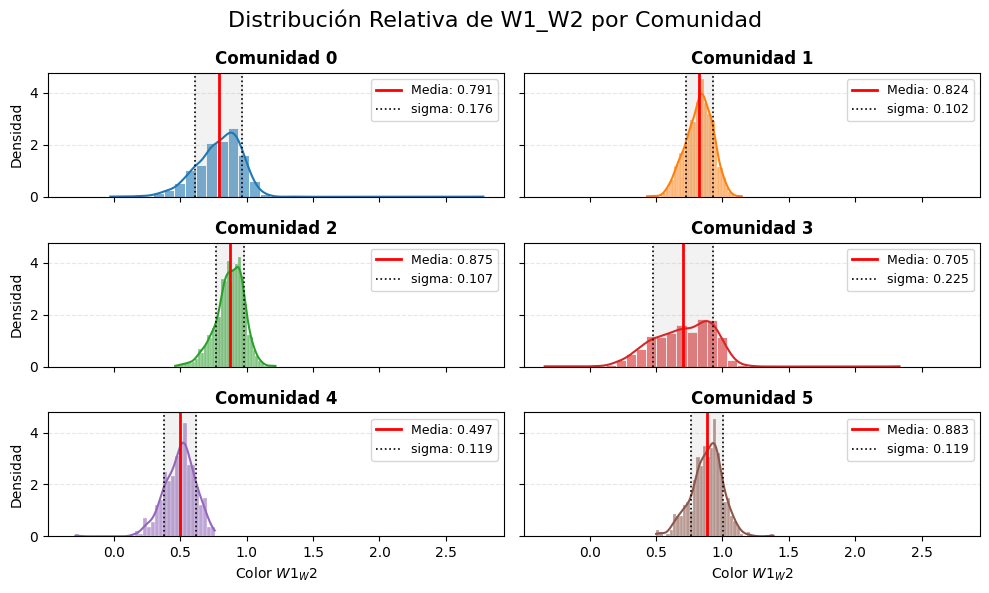

In [11]:
variable = 'W1_W2'

# Configuración 3x2
fig, axes = plt.subplots(3, 2, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()

for i, df_temp in enumerate(dfs):
    ax = axes[i]
    
    media = df_temp[variable].mean()
    desv_est = df_temp[variable].std()

    # Graficamos el histograma RELATIVO (Normalizado)
    sns.histplot(
        data=df_temp, 
        x=variable, 
        ax=ax, 
        stat="density",
        kde=True,
        color=f'C{i}', 
        bins=35, 
        alpha=0.6,
        edgecolor='white'
    )

    # Línea vertical de la Media
    ax.axvline(
        media, 
        color='red', 
        linestyle='-', 
        linewidth=2, 
        label=f'Media: {media:.3f}'
    )
    
    # Representación de la Desviación Estándar
    ax.axvline(media - desv_est, color='black', linestyle=':', linewidth=1.2, label=f'sigma: {desv_est:.3f}')
    ax.axvline(media + desv_est, color='black', linestyle=':', linewidth=1.2)
    
    # Opcional: Sombreado de la región central (1 sigma) para mayor claridad visual
    ax.axvspan(media - desv_est, media + desv_est, color='gray', alpha=0.1)
    
    # Estética y leyendas
    ax.set_title(f'Comunidad {i}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9, frameon=True)
    
    # Etiquetas de ejes
    if i % 2 == 0: ax.set_ylabel('Densidad')
    if i >= 4: ax.set_xlabel(f'Color ${variable}$')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
plt.suptitle(f'Distribución Relativa de {variable} por Comunidad', fontsize=16, y=.98)
plt.tight_layout()
plt.show()

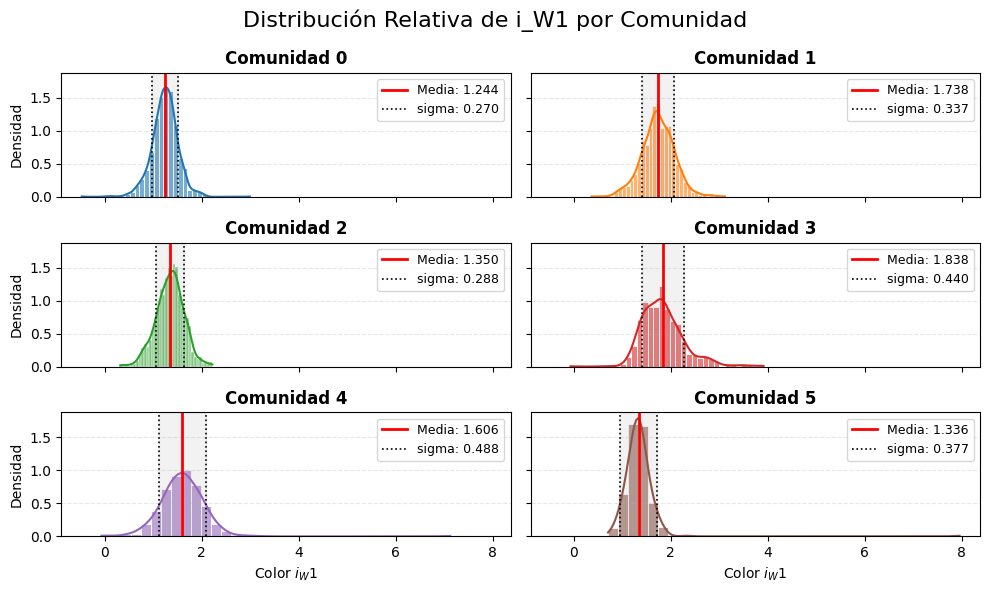

In [12]:
variable = 'i_W1'

# Configuración 3x2
fig, axes = plt.subplots(3, 2, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()

for i, df_temp in enumerate(dfs):
    ax = axes[i]

    df_temp["i_W1"] = df_temp["M_i"] - df_temp["M_W1"]
    
    media = df_temp[variable].mean()
    desv_est = df_temp[variable].std()

    # Graficamos el histograma
    sns.histplot(
        data=df_temp, 
        x=variable, 
        ax=ax, 
        stat="density",
        kde=True,
        color=f'C{i}', 
        bins=35, 
        alpha=0.6,
        edgecolor='white'
    )

    # Línea vertical de la Media
    ax.axvline(
        media, 
        color='red', 
        linestyle='-', 
        linewidth=2, 
        label=f'Media: {media:.3f}'
    )
    
    # Representación de la Desviación Estándar 
    ax.axvline(media - desv_est, color='black', linestyle=':', linewidth=1.2, label=f'sigma: {desv_est:.3f}')
    ax.axvline(media + desv_est, color='black', linestyle=':', linewidth=1.2)
    
    # Sombreado de la región central (1 sigma) para mayor claridad visual
    ax.axvspan(media - desv_est, media + desv_est, color='gray', alpha=0.1)
    
    # Estética y leyendas
    ax.set_title(f'Comunidad {i}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9, frameon=True)
    
    # Etiquetas de ejes
    if i % 2 == 0: ax.set_ylabel('Densidad')
    if i >= 4: ax.set_xlabel(f'Color ${variable}$')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle(f'Distribución Relativa de {variable} por Comunidad', fontsize=16, y=.98)
plt.tight_layout()
plt.show()